In [4]:
# Gerekli kütüphaneleri yükle
!pip install torchcodec
!pip install soundfile

import os
import glob
import shutil
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
import librosa

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score
from tqdm import tqdm
from google.colab import drive

print("Kütüphaneler yüklendi.")

# Drive'ı bağla
drive.mount('/content/drive')

# Kaynak Yolları (Drive'daki klasörleriniz)
healthy_source = '/content/drive/MyDrive/Colab Notebooks/İşaretlenenler/healthy/other'
asthma_source = '/content/drive/MyDrive/Colab Notebooks/İşaretlenenler/asthma'

# Hedef klasörler (Colab Local - Hızlı Disk)
base_target = '/content/dataset'
healthy_target_dir = os.path.join(base_target, 'healthy')
asthma_target_dir = os.path.join(base_target, 'asthma')

if os.path.exists(base_target):
    shutil.rmtree(base_target)
os.makedirs(healthy_target_dir)
os.makedirs(asthma_target_dir)

print("Dosyalar taranıyor ve yerel diske kopyalanıyor (Bu işlem eğitimi hızlandırır)...")

def copy_files(source_folder, target_folder, label_name):
    count = 0
    for root, dirs, files in os.walk(source_folder):
        for file in files:
            if file.lower().endswith('.wav'):
                src_path = os.path.join(root, file)
                dst_path = os.path.join(target_folder, file)
                shutil.copy(src_path, dst_path)
                count += 1
    print(f"-> '{label_name}' için kopyalanan dosya sayısı: {count}")
    return count

h_count = copy_files(healthy_source, healthy_target_dir, "Sağlıklı (healthy)")
a_count = copy_files(asthma_source, asthma_target_dir, "Astım (asthma)")

print(f"\nİşlem Tamamlandı! Toplam Ses Dosyası: {h_count + a_count}")

Kütüphaneler yüklendi.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dosyalar taranıyor ve yerel diske kopyalanıyor (Bu işlem eğitimi hızlandırır)...
-> 'Sağlıklı (healthy)' için kopyalanan dosya sayısı: 667
-> 'Astım (asthma)' için kopyalanan dosya sayısı: 477

İşlem Tamamlandı! Toplam Ses Dosyası: 1144


In [5]:
TARGET_SAMPLE_RATE = 16000
INPUT_LENGTH = 48000 # 3 Saniye

class ExpertRespiratoryDataset(Dataset):
    def __init__(self, file_list, labels, is_train=False):
        self.file_list = file_list
        self.labels = labels
        self.is_train = is_train

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=TARGET_SAMPLE_RATE,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )

        # SpecAugment (Sadece Eğitim Aşamasında Rastgele Maskeleme Yapar)
        self.freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
        self.time_masking = torchaudio.transforms.TimeMasking(time_mask_param=35)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(file_path)

        if sr != TARGET_SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)
            waveform = resampler(waveform)

        if waveform.shape[1] < INPUT_LENGTH:
            pad = INPUT_LENGTH - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :INPUT_LENGTH]

        mel = self.mel_transform(waveform)
        mel = torch.log(mel + 1e-9)

        # Veri Artırımı (Sadece eğitimdeyken maskeleme yap)
        if self.is_train:
            mel = self.freq_masking(mel)
            mel = self.time_masking(mel)

        return mel, torch.tensor(label, dtype=torch.long)

# Dosyaları topla ve etiketle (0: Sağlıklı, 1: Astım)
healthy_files = glob.glob("/content/dataset/healthy/*.wav")
asthma_files = glob.glob("/content/dataset/asthma/*.wav")

files = healthy_files + asthma_files
labels = [0]*len(healthy_files) + [1]*len(asthma_files)

# Train - Test Split
train_files, test_files, train_labels, test_labels = train_test_split(
    files, labels, test_size=0.2, stratify=labels, random_state=42
)

# Datasetleri oluştur (Eğitim seti is_train=True)
train_dataset = ExpertRespiratoryDataset(train_files, train_labels, is_train=True)
test_dataset = ExpertRespiratoryDataset(test_files, test_labels, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Dataloader hazır. Train: {len(train_files)}, Test: {len(test_files)}")

Dataloader hazır. Train: 915, Test: 229


In [6]:
class Expert_CNN_BiGRU(nn.Module):
    def __init__(self, num_classes=2, dropout_prob=0.3):
        super(Expert_CNN_BiGRU, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1), # Dropout eklendi

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2)
        )

        self.bigru = nn.GRU(
            input_size=128 * 16,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_prob
        )

        self.fc_dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        b, c, f, t = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, t, c * f)

        x, _ = self.bigru(x)
        x = x[:, -1, :] # Son zaman adımını al

        x = self.fc_dropout(x)
        x = self.fc(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Expert_CNN_BiGRU(num_classes=2).to(device)
print(model)

Expert_CNN_BiGRU(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.2, inplace=False)
  )
  (bigru): GRU(2048, 128, num_layers

In [9]:
# -----------------------------
# SINIF AĞIRLIKLARININ HESAPLANMASI
# -----------------------------
num_healthy = labels.count(0)
num_asthma = labels.count(1)
total_samples = num_healthy + num_asthma

# Astım sınıfı az olduğu için loss fonksiyonunda cezası daha büyük olacak
weight_for_0 = total_samples / (2.0 * num_healthy)
weight_for_1 = total_samples / (2.0 * num_asthma)
class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights) # Sınıf ağırlıkları uygulandı

# verbose=True parametresi PyTorch'un yeni sürümlerinde kaldırıldığı için silindi.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 40
patience = 7
best_loss = float('inf')
counter = 0

train_f1_history, test_f1_history = [], []
train_iou_history, test_iou_history = [], []

def run_epoch(loader, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    desc = "Eğitim" if is_train else "Test"
    loop = tqdm(loader, desc=desc, leave=False, file=sys.stdout)

    for inputs, lbls in loop:
        inputs, lbls = inputs.to(device), lbls.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, lbls)

            if is_train:
                if torch.isnan(loss): continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += lbls.size(0)
        correct += (preds == lbls).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    iou = jaccard_score(all_labels, all_preds, average='binary', zero_division=0)
    return avg_loss, acc, f1, iou

best_model_wts = copy.deepcopy(model.state_dict())

print(f"\n--- UZMAN EĞİTİM BAŞLIYOR (Cihaz: {device}) ---\n")

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1, train_iou = run_epoch(train_loader, is_train=True)
    test_loss, test_acc, test_f1, test_iou = run_epoch(test_loader, is_train=False)

    # Scheduler test loss'a göre Learning Rate günceller
    scheduler.step(test_loss)

    train_f1_history.append(train_f1)
    test_f1_history.append(test_f1)
    train_iou_history.append(train_iou)
    test_iou_history.append(test_iou)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} (Mevcut LR: {current_lr})")
    print(f"TRAIN -> Loss: {train_loss:.4f} | Acc: %{train_acc:.2f} | F1: {train_f1:.3f} | IoU: {train_iou:.3f}")
    print(f"TEST  -> Loss: {test_loss:.4f} | Acc: %{test_acc:.2f} | F1: {test_f1:.3f} | IoU: {test_iou:.3f}")

    if test_loss < best_loss:
        best_loss = test_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
        torch.save(model.state_dict(), "uzman_oksuruk_modeli.pth")
        print("   -> (Yeni En İyi Model Kaydedildi)")
    else:
        counter += 1
        print(f"   -> İyileşme yok. Sayaç: {counter}/{patience}")
        if counter >= patience:
            print("\n--- ERKEN DURDURMA (EARLY STOPPING) ---")
            break
    print("-" * 60)

model.load_state_dict(best_model_wts)
print(f"\nEğitim bitti. En iyi Test Kaybı: {best_loss:.4f}")


--- UZMAN EĞİTİM BAŞLIYOR (Cihaz: cuda) ---

Epoch 1/40 (Mevcut LR: 0.0005)
TRAIN -> Loss: 0.7271 | Acc: %47.76 | F1: 0.404 | IoU: 0.253
TEST  -> Loss: 0.6841 | Acc: %69.00 | F1: 0.575 | IoU: 0.403
   -> (Yeni En İyi Model Kaydedildi)
------------------------------------------------------------
Epoch 2/40 (Mevcut LR: 0.0005)
TRAIN -> Loss: 0.7089 | Acc: %52.46 | F1: 0.454 | IoU: 0.294
TEST  -> Loss: 0.6925 | Acc: %58.52 | F1: 0.000 | IoU: 0.000
   -> İyileşme yok. Sayaç: 1/7
------------------------------------------------------------
Epoch 3/40 (Mevcut LR: 0.0005)
TRAIN -> Loss: 0.6971 | Acc: %55.63 | F1: 0.505 | IoU: 0.338
TEST  -> Loss: 0.6626 | Acc: %71.18 | F1: 0.621 | IoU: 0.450
   -> (Yeni En İyi Model Kaydedildi)
------------------------------------------------------------
Epoch 4/40 (Mevcut LR: 0.0005)
TRAIN -> Loss: 0.6642 | Acc: %59.23 | F1: 0.531 | IoU: 0.361
TEST  -> Loss: 0.6414 | Acc: %69.43 | F1: 0.624 | IoU: 0.453
   -> (Yeni En İyi Model Kaydedildi)
-----------------

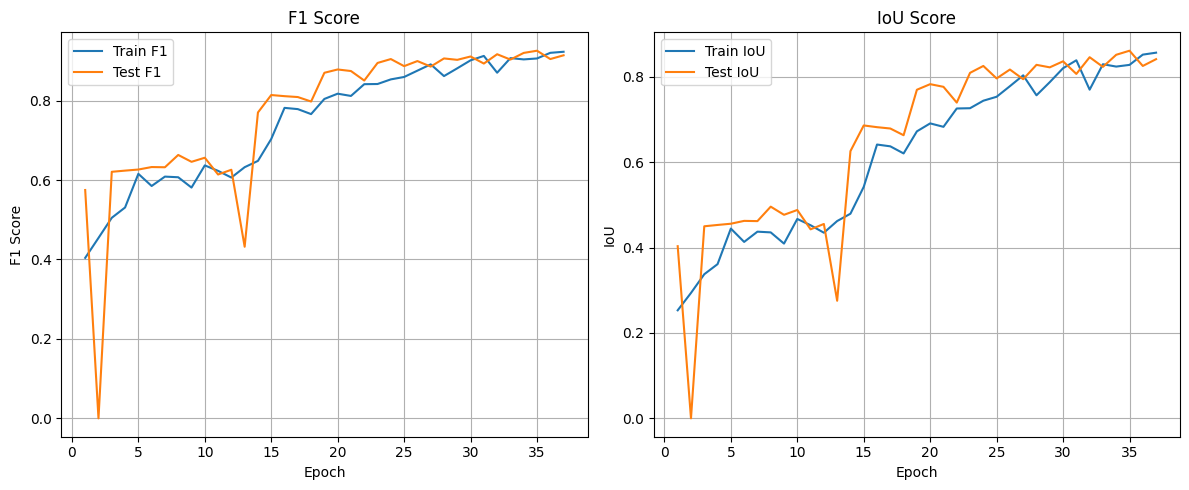

In [10]:
epochs = range(1, len(train_f1_history)+1)
plt.figure(figsize=(12,5))

# F1 SCORE
plt.subplot(1,2,1)
plt.plot(epochs, train_f1_history, label="Train F1")
plt.plot(epochs, test_f1_history, label="Test F1")
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()

# IoU
plt.subplot(1,2,2)
plt.plot(epochs, train_iou_history, label="Train IoU")
plt.plot(epochs, test_iou_history, label="Test IoU")
plt.title("IoU Score")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [14]:
# --- TAHMİN FONKSİYONU ---
def process_and_predict(segment, sr, eval_model):
    tensor = torch.from_numpy(segment).float()

    if tensor.shape[0] > INPUT_LENGTH:
        center = tensor.shape[0] // 2
        start = center - (INPUT_LENGTH // 2)
        tensor = tensor[start:start + INPUT_LENGTH]
    elif tensor.shape[0] < INPUT_LENGTH:
        padding = INPUT_LENGTH - tensor.shape[0]
        tensor = F.pad(tensor, (0, padding))

    waveform = tensor.unsqueeze(0)

    # Mel transform (Inference modunda masking yok)
    eval_mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE, n_fft=1024, hop_length=512, n_mels=128
    )

    mel = eval_mel_transform(waveform)
    mel = torch.log(mel + 1e-9)
    input_tensor = mel.unsqueeze(0).to(device)

    eval_model.eval()
    with torch.no_grad():
        output = eval_model(input_tensor)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    return pred.item(), conf.item()

# --- ANALİZ VE RAPORLAMA FONKSİYONU ---
def analyze_audio_file(file_path):
    print(f"ANALİZ BAŞLIYOR: {file_path}")
    print("-" * 50)

    if not os.path.exists(file_path):
        print(f"HATA: '{file_path}' yolunda dosya bulunamadı! Lütfen Drive yolunu kontrol edin.")
        return

    try:
        # Sesi yükle
        y, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE)
    except Exception as e:
        print(f"Dosya okuma hatası: {e}")
        return

    # Sesi sessiz kısımlardan ayır (Öksürükleri bulur)
    intervals = librosa.effects.split(y, top_db=25) # Hassasiyeti biraz artırdım (25db)
    votes = {"healthy": 0, "asthma": 0}

    if len(intervals) == 0:
        print("Ses dosyasında analiz edilecek anlamlı bir ses bulunamadı.")
        return

    print(f"Tespit edilen ses parçası sayısı: {len(intervals)}\n")

    for i, (start, end) in enumerate(intervals):
        segment = y[start:end]

        # Çok kısa parçaları (0.2 saniyeden az) gürültü say ve geç
        if len(segment) < (0.2 * TARGET_SAMPLE_RATE):
            continue

        label_idx, confidence = process_and_predict(segment, sr, model)
        label_str = "SAĞLIKLI" if label_idx == 0 else "ASTIM"

        # Renkli çıktı (Sadece terminal destekliyse)
        color = "\033[92m" if label_idx == 0 else "\033[91m"
        reset = "\033[0m"

        print(f"Segment {i+1}: {color}{label_str}{reset} (Güven: %{confidence*100:.2f})")

        # Güven oranı %55'ten büyükse oylamaya dahil et
        if confidence > 0.55:
            if label_idx == 0:
                votes["healthy"] += 1
            else:
                votes["asthma"] += 1

    print("-" * 50)
    print("GENEL ANALİZ SONUCU:")
    total_votes = votes["healthy"] + votes["asthma"]

    if total_votes == 0:
        print("Model tahmin yürütmek için yeterli güven oranına ulaşamadı.")
    else:
        print(f"Astım Oyu: {votes['asthma']} | Sağlıklı Oyu: {votes['healthy']}")
        if votes["asthma"] > votes["healthy"]:
            print("\nSONUÇ: ⚠️ TEST POZİTİF (ASTIM BELİRTİLERİ) ⚠️")
        elif votes["healthy"] > votes["asthma"]:
            print("\nSONUÇ: ✅ TEST NEGATİF (SAĞLIKLI) ✅")
        else:
            print("\nSONUÇ: ⚖️ BELİRSİZ (Eşitlik söz konusu)")

# --- ÇALIŞTIRMA KOMUTU ---
# Drive yolunun başına mutlaka /content/drive/MyDrive/... geldiğinden emin olun.
test_file_yolu = "/content/drive/MyDrive/Colab Notebooks/isaretsiz/1(16).wav"

# Fonksiyonu burada çağırıyoruz:
analyze_audio_file(test_file_yolu)

ANALİZ BAŞLIYOR: /content/drive/MyDrive/Colab Notebooks/isaretsiz/1(16).wav
--------------------------------------------------
Tespit edilen ses parçası sayısı: 8

Segment 1: ASTIM (Güven: %99.54)
Segment 2: ASTIM (Güven: %99.45)
Segment 3: ASTIM (Güven: %99.46)
Segment 4: ASTIM (Güven: %62.63)
Segment 5: ASTIM (Güven: %97.98)
Segment 6: ASTIM (Güven: %97.69)
Segment 7: ASTIM (Güven: %99.11)
Segment 8: ASTIM (Güven: %96.73)
--------------------------------------------------
GENEL ANALİZ SONUCU:
Astım Oyu: 8 | Sağlıklı Oyu: 0

SONUÇ: ⚠️ TEST POZİTİF (ASTIM BELİRTİLERİ) ⚠️


In [26]:
deneme_listesi = ["1(16).wav","1(27).wav","1(94).wav","2(68).wav","2(78).wav","2(80).wav","2 (39).wav","oksuruk.wav","kendi_oksurugum.wav"]

for i in deneme_listesi:
    test_file_yolu = f"/content/drive/MyDrive/Colab Notebooks/isaretsiz/{i}"
    analyze_audio_file(test_file_yolu)

ANALİZ BAŞLIYOR: /content/drive/MyDrive/Colab Notebooks/isaretsiz/1(16).wav
--------------------------------------------------
Tespit edilen ses parçası sayısı: 8

Segment 1: ASTIM (Güven: %99.54)
Segment 2: ASTIM (Güven: %99.45)
Segment 3: ASTIM (Güven: %99.46)
Segment 4: ASTIM (Güven: %62.63)
Segment 5: ASTIM (Güven: %97.98)
Segment 6: ASTIM (Güven: %97.69)
Segment 7: ASTIM (Güven: %99.11)
Segment 8: ASTIM (Güven: %96.73)
--------------------------------------------------
GENEL ANALİZ SONUCU:
Astım Oyu: 8 | Sağlıklı Oyu: 0

SONUÇ: ⚠️ TEST POZİTİF (ASTIM BELİRTİLERİ) ⚠️
ANALİZ BAŞLIYOR: /content/drive/MyDrive/Colab Notebooks/isaretsiz/1(27).wav
--------------------------------------------------
Tespit edilen ses parçası sayısı: 2

Segment 2: ASTIM (Güven: %98.88)
--------------------------------------------------
GENEL ANALİZ SONUCU:
Astım Oyu: 1 | Sağlıklı Oyu: 0

SONUÇ: ⚠️ TEST POZİTİF (ASTIM BELİRTİLERİ) ⚠️
ANALİZ BAŞLIYOR: /content/drive/MyDrive/Colab Notebooks/isaretsiz/1(94).wav